In [1]:
from torch.utils.data import Dataset, DataLoader

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from dataset import PineappleDataset
from vae.vq_vae import VQVAE

In [ ]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def extract_and_visualize_latents(model, test_loader, device='cuda'):
    model.eval()
    model.to(device)

    all_latents = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device)
            latent = model.encoder(input_tensor)

            all_latents.append(latent.squeeze(0).cpu().numpy())

    # Stack latents
    all_latents = np.stack(all_latents)
    print(f"{all_latents.shape[0]} latent vectors extracted")

    # Reshape to 2D and remove NaNs
    reshaped_data = all_latents.reshape(all_latents.shape[0], -1)
    nan_mask = ~np.isnan(reshaped_data).any(axis=1)
    data_cleaned = reshaped_data[nan_mask]

    print(f"Cleaned data shape: {data_cleaned.shape}")

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    clustered_data = tsne.fit_transform(data_cleaned)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(clustered_data[:, 0], clustered_data[:, 1], alpha=0.7)
    plt.title("t-SNE Clustering of Flattened Latents")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def visualize_reconstructions(model, test_set, num_samples=5, device='cuda'):
    """
    Visualizes original and reconstructed images side by side.
    
    Args:
        model: Trained model with a forward method that returns reconstructions.
        test_set: Dataset providing dicts with 'image' keys.
        num_samples: Number of random samples to display.
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    model.to(device)

    fig = plt.figure(figsize=(4 * num_samples, 8))  # Wide figure
    rows, columns = 2, num_samples  # Original + reconstructed rows

    for i in range(columns):
        index = np.random.randint(len(test_set))

        # Get original image and convert to tensor
        original_image = test_set[index]['image']
        input_tensor = torch.tensor(original_image).unsqueeze(0).to(device)

        # Model inference
        with torch.no_grad():
            reconstructed_image, _, _, _ = model(input_tensor)

        # Convert images for display
        original_image_disp = (original_image.transpose((1, 2, 0)) * 255).astype(np.uint8)
        reconstructed_image = reconstructed_image.squeeze(0).cpu().numpy()
        reconstructed_image_disp = (reconstructed_image.transpose((1, 2, 0)) * 255).astype(np.uint8)

        # Plot original
        ax = fig.add_subplot(rows, columns, i + 1)
        ax.set_title('Original')
        ax.imshow(original_image_disp)
        ax.axis('off')

        # Plot reconstructed
        ax = fig.add_subplot(rows, columns, i + 1 + columns)
        ax.set_title('Reconstructed')
        ax.imshow(reconstructed_image_disp)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
test_set = PineappleDataset(train=False, train_ratio=0.8, path="./FULL_VERTICAL_PINEAPPLE/FULL_UNIFIED")
test_loader = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=2)

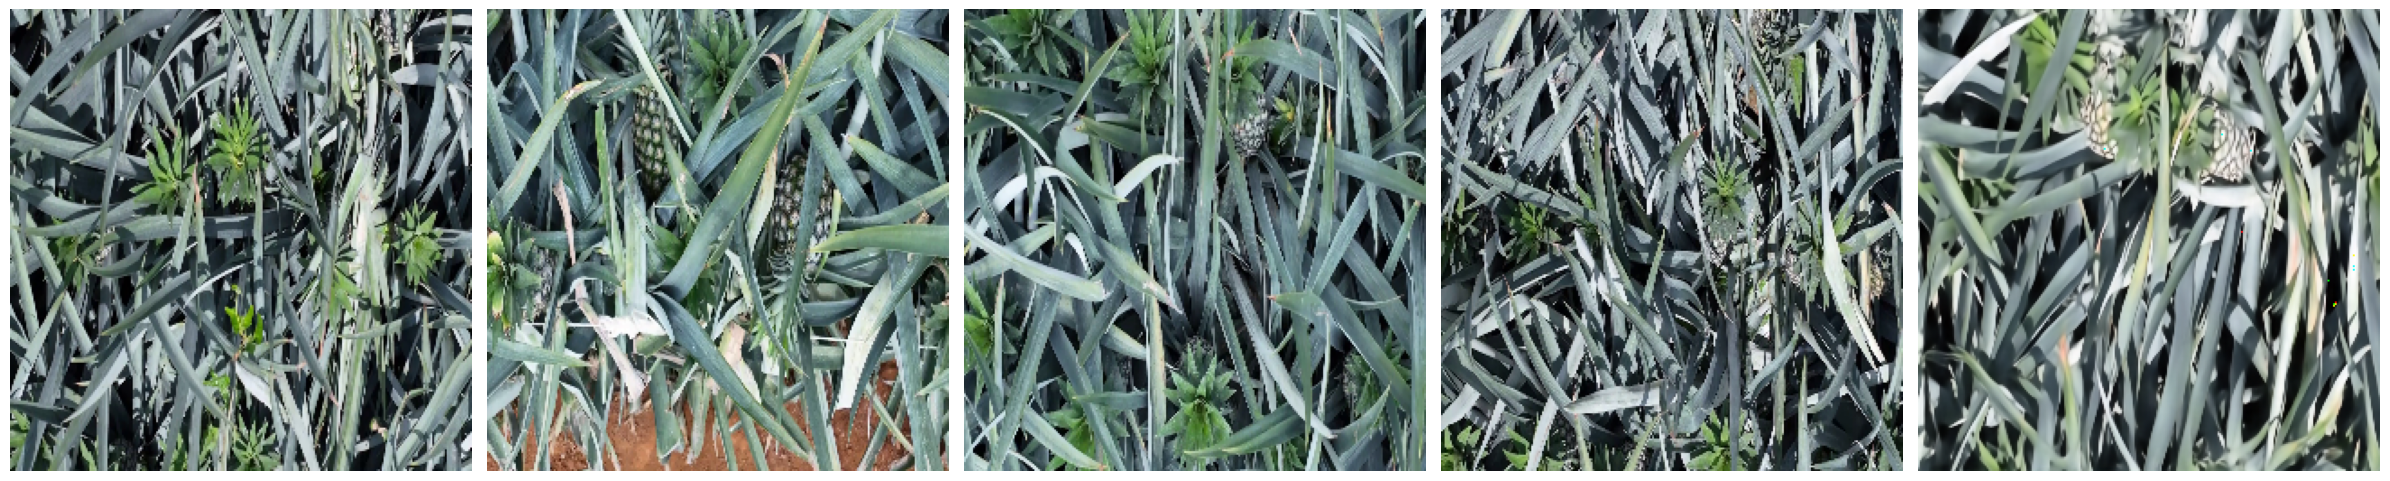

In [4]:
fig = plt.figure(figsize=(24, 6))  # Wider and shorter for horizontal layout
rows = 1
columns = 5

for i in range(columns):
    batch = test_set[np.random.randint(len(test_set))]
    img = batch['image'].transpose((1, 2, 0))  # Convert CHW to HWC
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide axis for better presentation

plt.tight_layout()
plt.show()

In [5]:
model = VQVAE()
checkpoint_path = "/home/rtxmsi1/Documents/VAE_training-master/checkpoints/vqvae/weights_ck_199.pt"  # Replace with your checkpoint file
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

<All keys matched successfully>

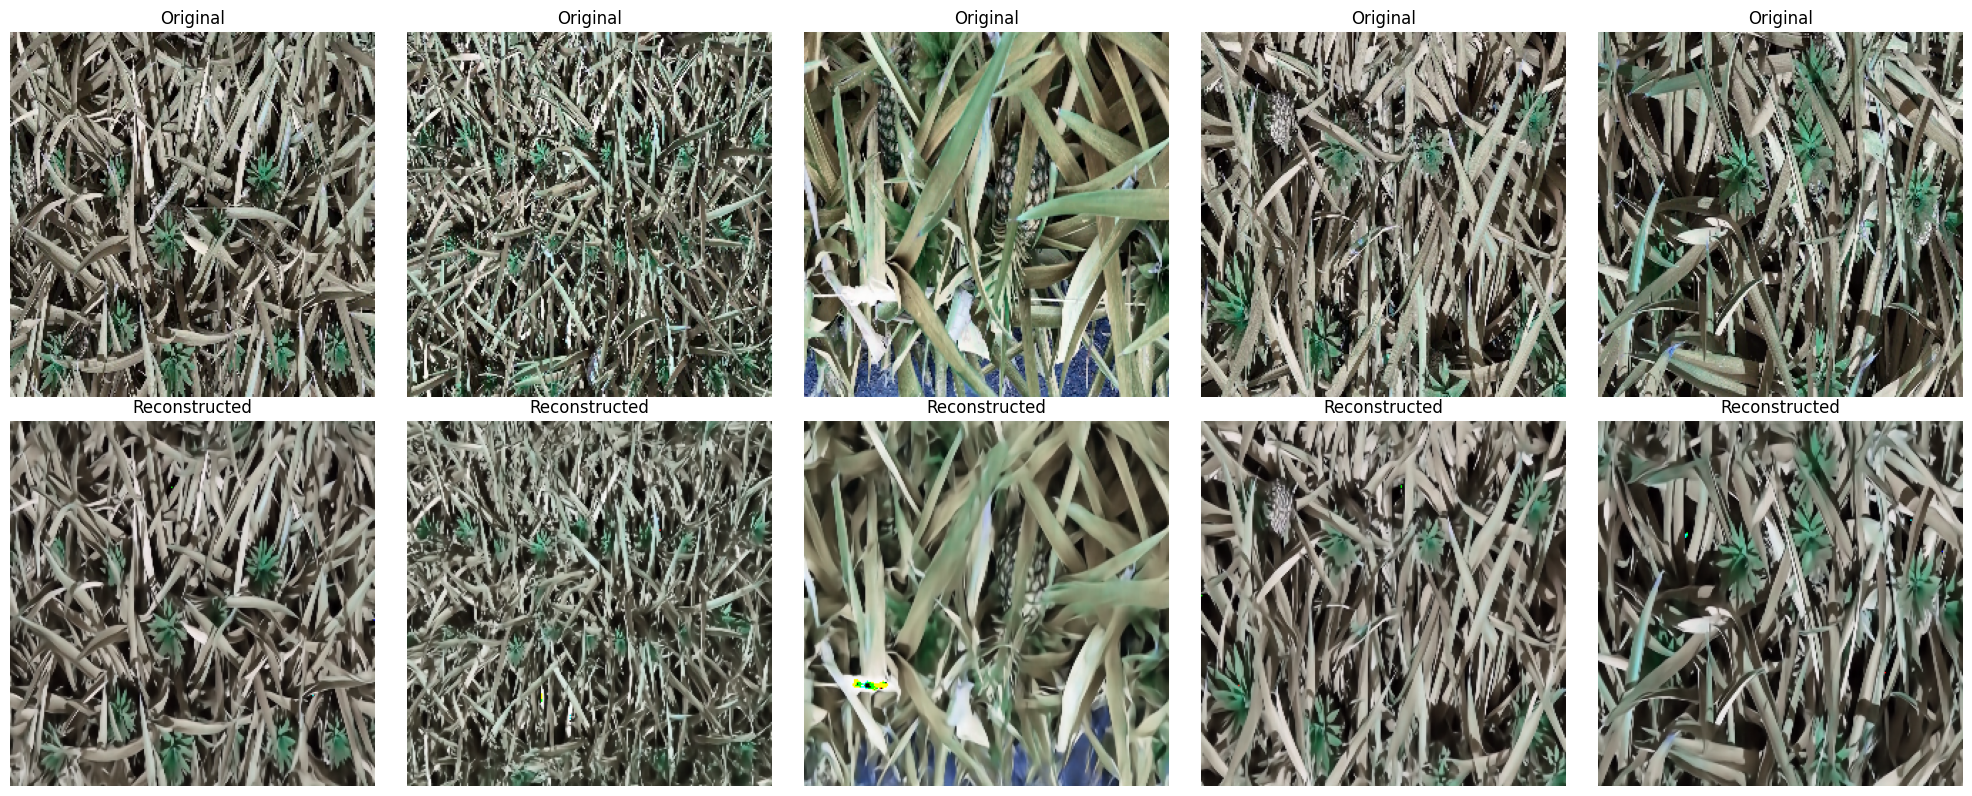

In [8]:
visualize_reconstructions(model, test_set, num_samples=5)

982 latent vectors extracted
Cleaned data shape: (982, 131072)


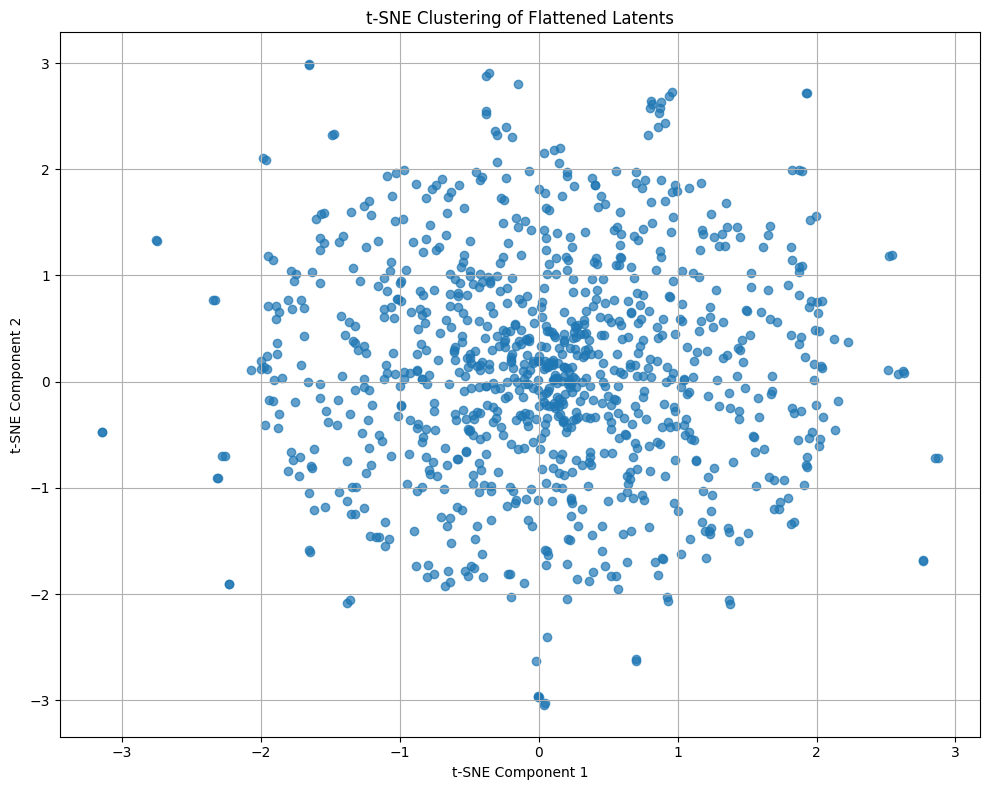

In [13]:
extract_and_visualize_latents(model, test_loader)

In [14]:
model = VQVAE()
checkpoint_path = "/home/rtxmsi1/Documents/VAE_training-master/checkpoints/vqvae/weights_ck_0.pt"  # Replace with your checkpoint file
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint)

<All keys matched successfully>

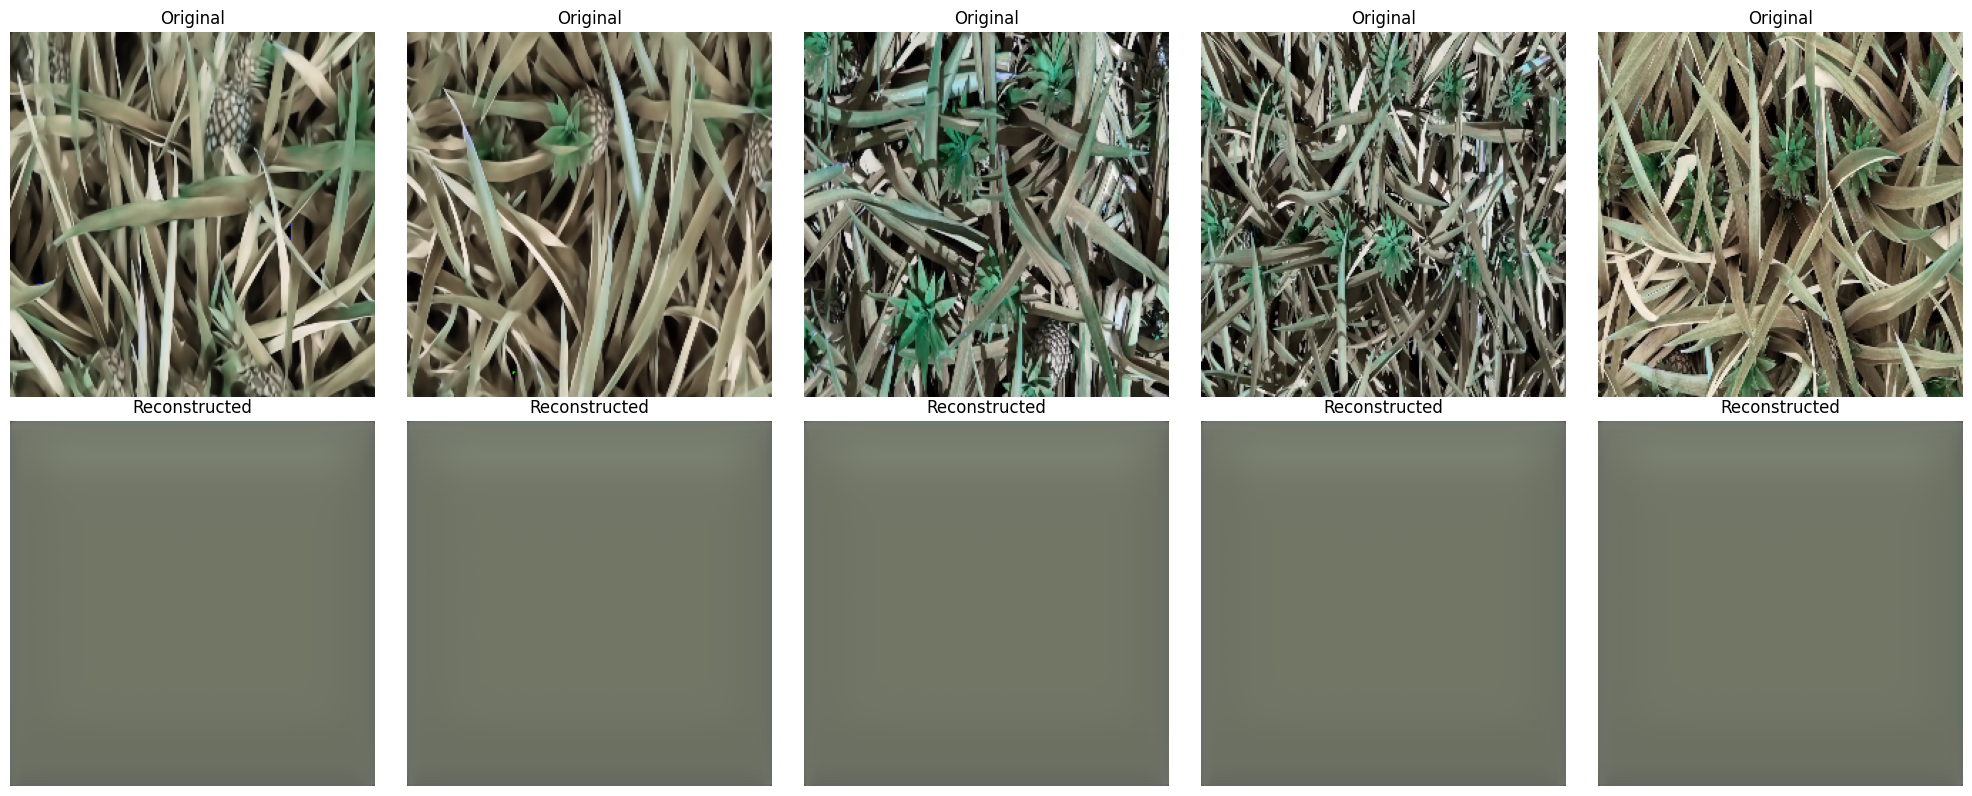

In [15]:
visualize_reconstructions(model, test_set, num_samples=5)

982 latent vectors extracted
Cleaned data shape: (982, 131072)


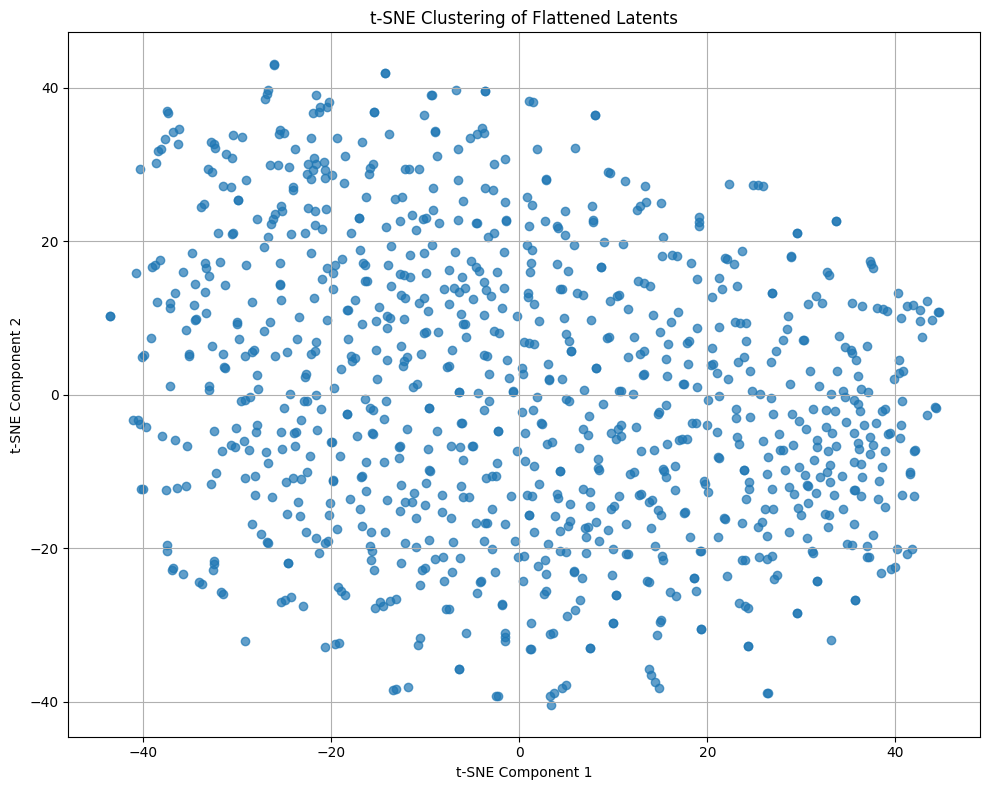

In [16]:
extract_and_visualize_latents(model, test_loader)